In [2]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as colors
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas
import random
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [3]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

# Sample HyperGraph Visulization

Generating hyper edges for order 2...


105it [00:00, 51310.95it/s]


Generating hyper edges for order 3...


455it [00:00, 24100.63it/s]


Generating hyper edges for order 4...


1365it [00:00, 35882.00it/s]

# of nodes 15, # of edges 13


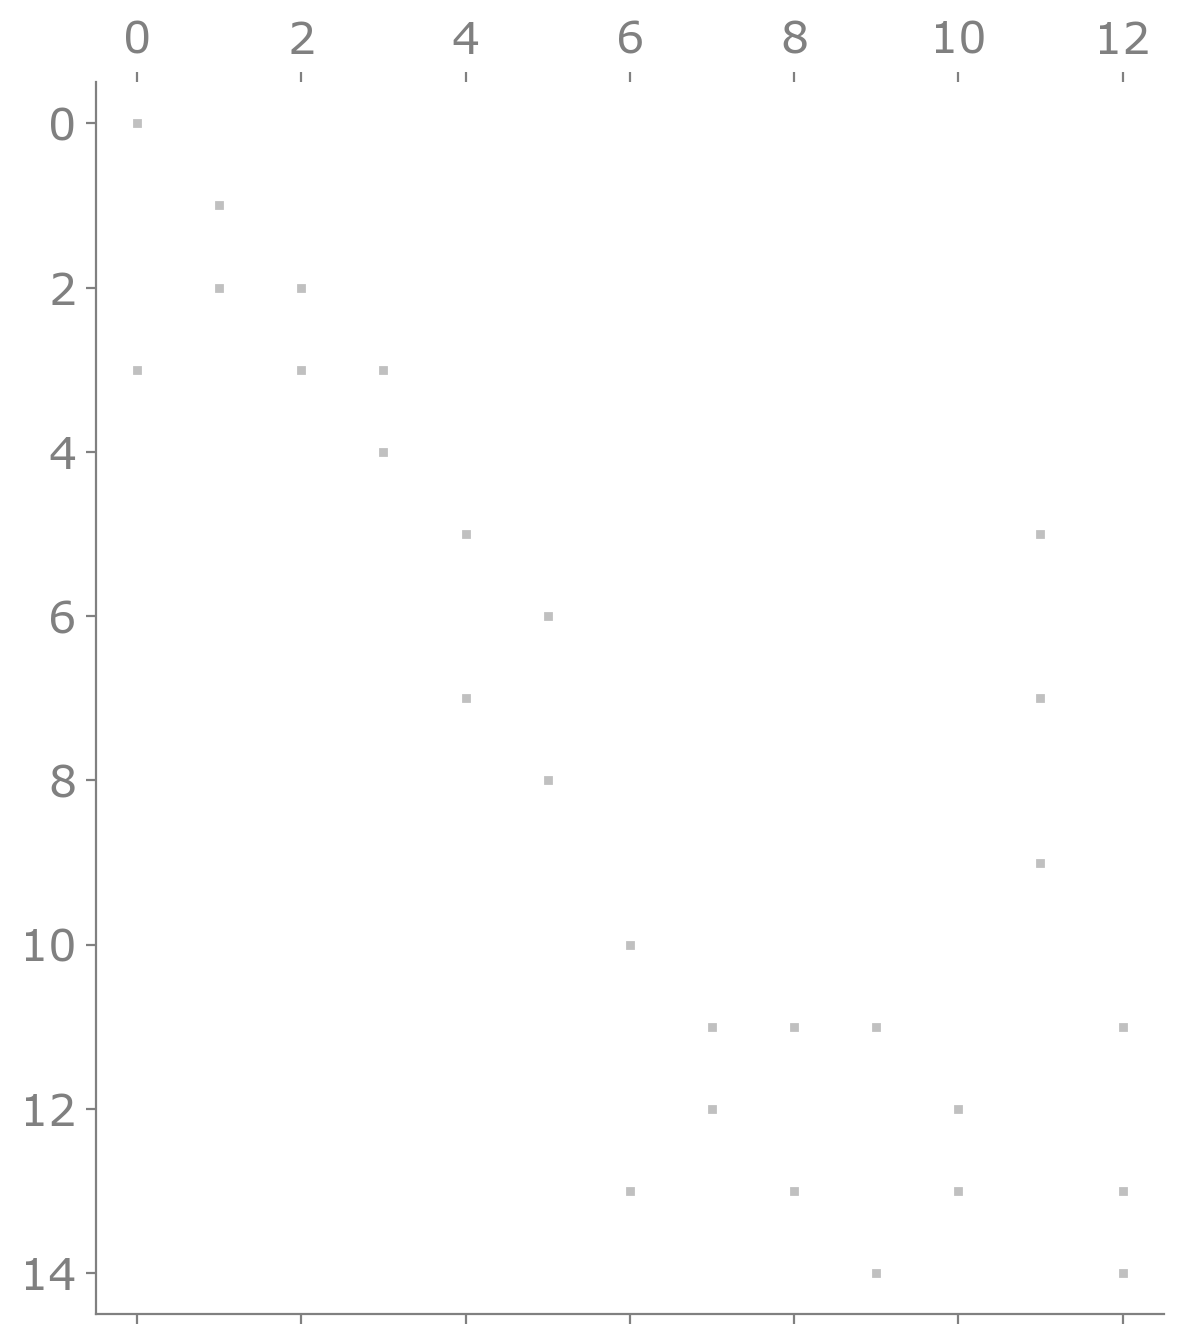

In [94]:
n = 15
q = 3
Ks = [2, 3, 4]
cin = 5
cout = 0.1
hsbm = UnUniformSymmetricHSBM(n, q, Ks, cin, cout)
print(f'# of nodes {hsbm.n}, # of edges {hsbm.e}')
fig = plt.figure(figsize=(8, 8))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
plt.spy(hsbm.H, markersize=2, rasterized=True, color=gray)

In [112]:
H = hsbm.H.toarray()
H[10, 12] = 1
H[2, 0] = 1
H[14, 10] = 1
H[6, 4] = 1
H[4, 3] = 0
H[6, 3] = 1
H[11, 7] = 0
H[6, 7] = 1
H[7, 5] = 0

In [113]:
# Construct EdgeList
edgeList = []
for hedge_id in range(hsbm.e):
    hedge = csc_matrix(H).getcol(hedge_id).nonzero()[0]
    edgeList.append(hedge)
hgx_hypergraph = hgx.core.hypergraph.Hypergraph(edgeList)

In [33]:
u_meta = np.zeros(shape=(hsbm.n, 2))
for i in range(hsbm.n):
    if i < 5:
        u_meta[i][0] = 1
    else:
        u_meta[i][1] = 1

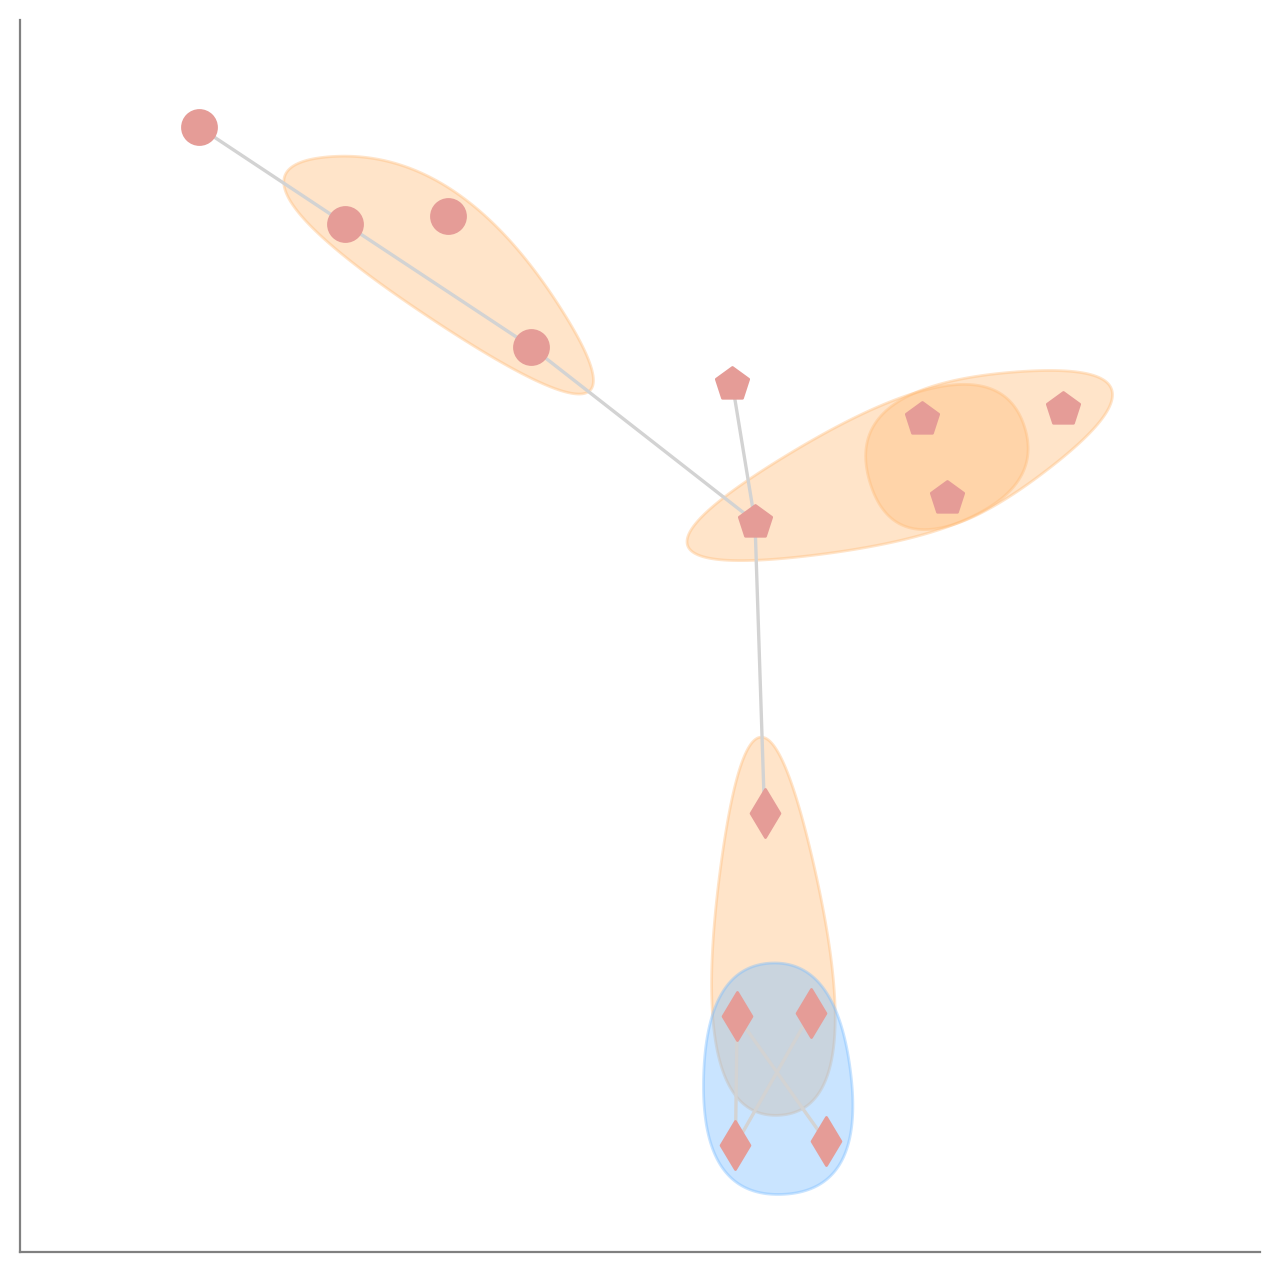

In [119]:
shapes = ['o'] * 5
shapes.extend(['p'] * 5)
shapes.extend(['d'] * 5)
fig = plt.figure(figsize=(8, 8))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
# draw_communities(hypergraph=hgx_hypergraph, u=u_meta, col=color, ax=ax, node_size=0.05, with_node_labels=True, title='')
draw_hypergraph(hypergraph=hgx_hypergraph, ax=ax, with_node_labels=False, hyperedge_alpha=0.4, seed=int(10 * random.random()), scale=0.5, iterations=1000, 
                node_shape=shapes, node_color="#E59C97", node_facecolor="#E59C97")
fig.savefig("./_Figure/Hyper/simpleSampleHyper.svg")

# matrix tensor form

In [14]:
n = 15
q = 3
Ks = [2]
cin = 10
cout = 0.1
hsbm = UnUniformSymmetricHSBM(n, q, Ks, cin, cout)
print(f'# of nodes {hsbm.n}, # of edges {hsbm.e}')

Generating hyper edges for order 2...


105it [00:00, 16941.14it/s]

# of nodes 15, # of edges 17


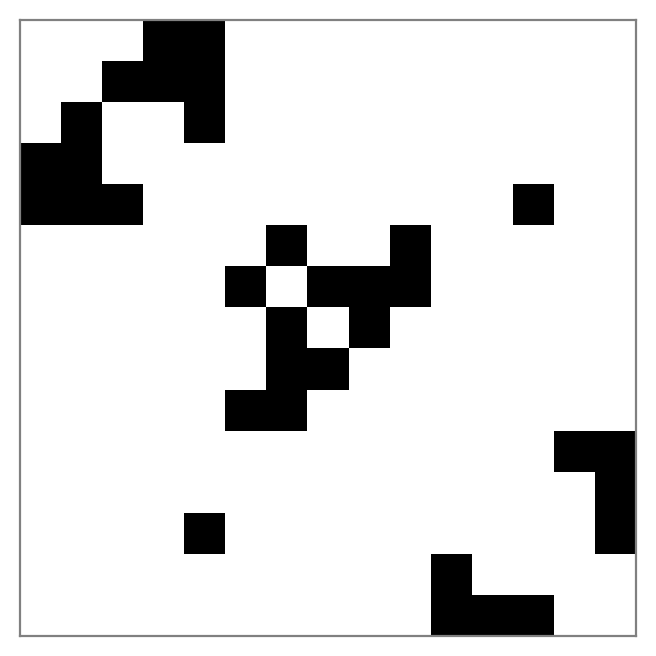

In [21]:
A = hsbm.H.dot(hsbm.H.T) - diags(hsbm.H.dot(hsbm.H.T).diagonal())
A = A.toarray()
fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(A, cmap="binary")
ax.set_xticks([])
ax.set_yticks([])
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

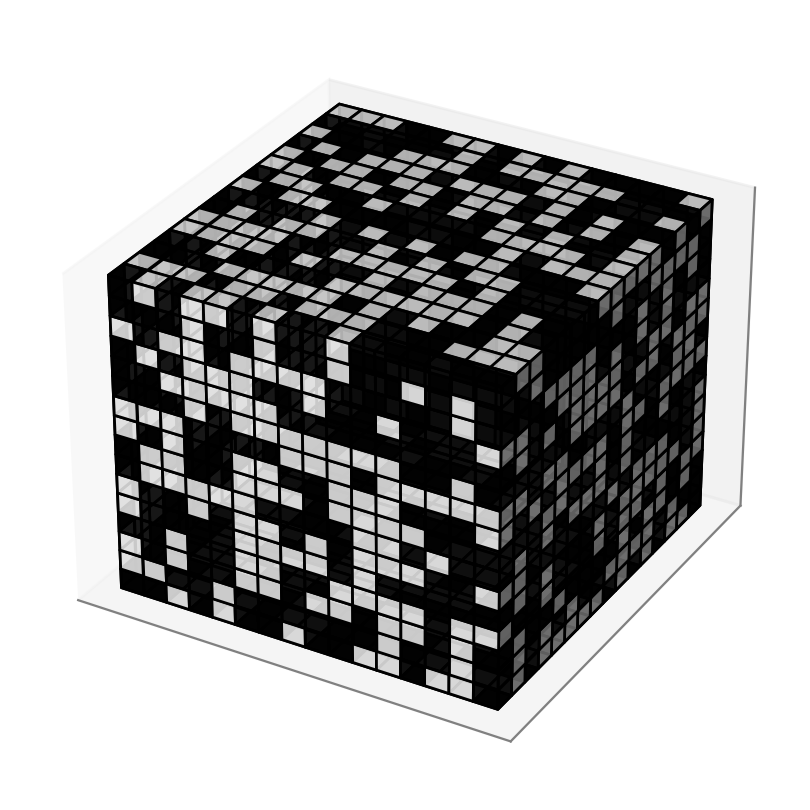

In [28]:
axes = [16, 16, 16] # change to 64
traj = np.random.choice([-1,1], axes)

alpha = 0.9
colors = np.empty(axes + [4], dtype=np.float32)
colors[traj==1] = [1, 1, 1, alpha]  # red
colors[traj==-1] = [0, 0, 0, alpha]  # blue

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.voxels(traj, facecolors=colors, edgecolors='black')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
plt.show()


In [43]:
n = 15
q = 3
Ks = [2, 3, 4]
cin = 100
cout = 10
hsbm = UnUniformSymmetricHSBM(n, q, Ks, cin, cout)
print(f'# of nodes {hsbm.n}, # of edges {hsbm.e}')

Generating hyper edges for order 2...


105it [00:00, 21002.52it/s]


Generating hyper edges for order 3...


455it [00:00, 32047.16it/s]


Generating hyper edges for order 4...


1365it [00:00, 38133.34it/s]

# of nodes 15, # of edges 120


(15, 56)


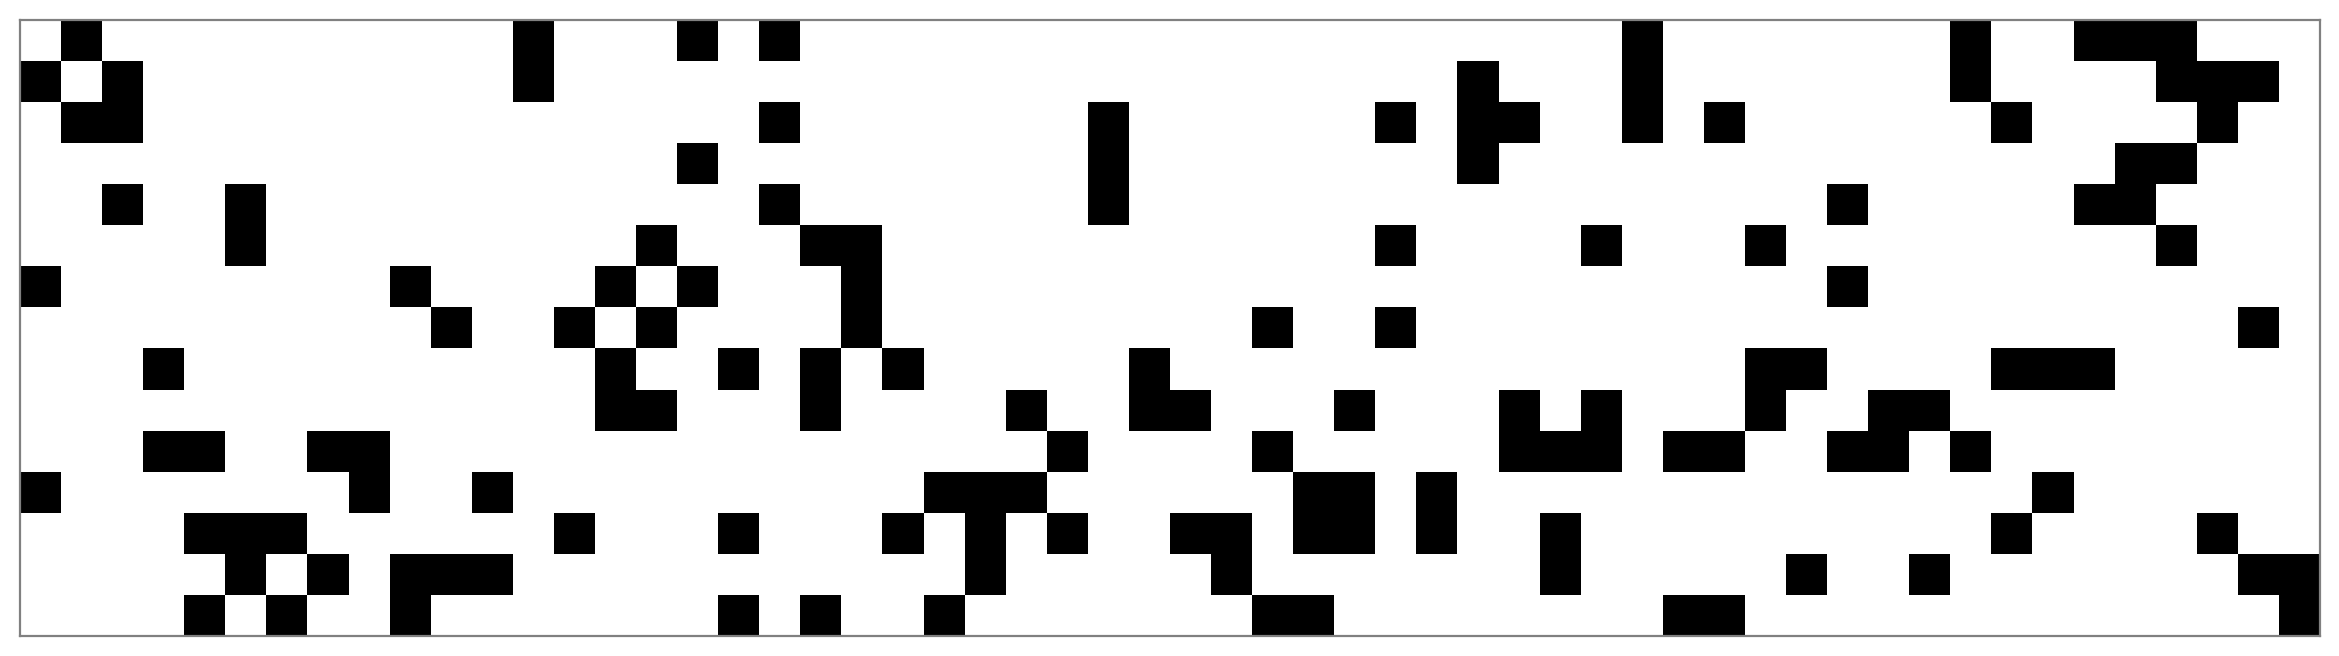

In [62]:
fig = plt.figure(figsize=(16, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
H = np.delete(hsbm.H.toarray(), np.arange(2, 66), 1)
col_index = np.arange(np.shape(H)[1])
np.random.shuffle(col_index)
H = H[:, col_index]
print(np.shape(H))
ax.matshow(H, cmap="binary")
ax.set_xticks([])
ax.set_yticks([])
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

# SBM HSBM parameter

In [4]:
n = 15
q = 3
Ks = [2, 3]
cin = 10
cout = 0.1
hsbm = UnUniformSymmetricHSBM(n, q, Ks, cin, cout)
print(f'# of nodes {hsbm.n}, # of edges {hsbm.e}')

Generating hyper edges for order 2...


105it [00:00, 14995.98it/s]


Generating hyper edges for order 3...


455it [00:00, 30688.71it/s]

# of nodes 15, # of edges 22


[[0.66666667 0.00666667 0.00666667]
 [0.00666667 0.66666667 0.00666667]
 [0.00666667 0.00666667 0.66666667]]


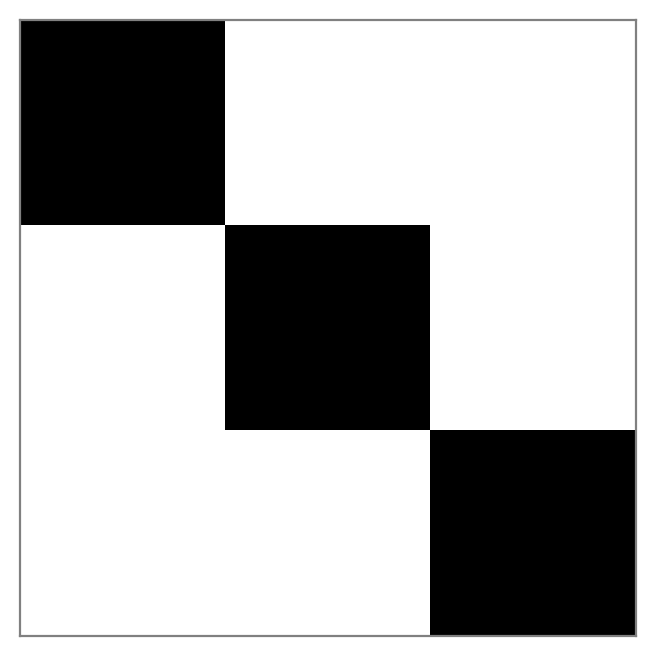

In [8]:
fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
print(hsbm.ps_dict[2])
ax.matshow(hsbm.ps_dict[2], cmap="binary")
ax.set_xticks([])
ax.set_yticks([])
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

[[[0.04444444 0.00044444 0.00044444]
  [0.00044444 0.00044444 0.00044444]
  [0.00044444 0.00044444 0.00044444]]

 [[0.00044444 0.00044444 0.00044444]
  [0.00044444 0.04444444 0.00044444]
  [0.00044444 0.00044444 0.00044444]]

 [[0.00044444 0.00044444 0.00044444]
  [0.00044444 0.00044444 0.00044444]
  [0.00044444 0.00044444 0.04444444]]]


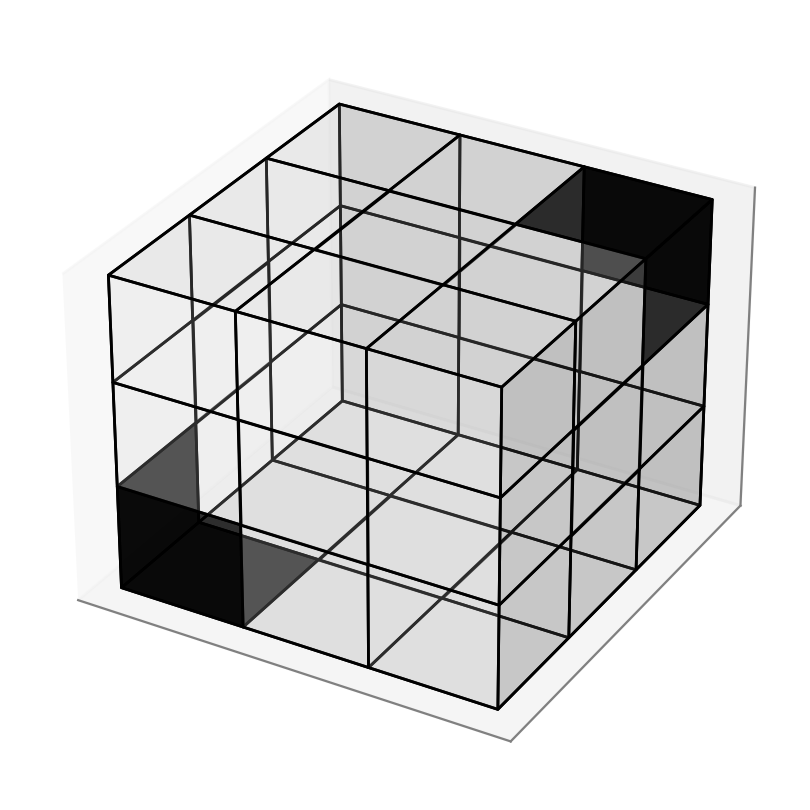

In [14]:
axes = [3, 3, 3] # change to 64
# traj = np.random.choice([-1,1], axes)
traj = hsbm.ps_dict[3]
print(traj)

alpha = 0.2
colors = np.empty(axes + [4], dtype=np.float32)
colors[traj<0.01] = [1, 1, 1, alpha]  # red
alpha = 0.8
colors[traj>=0.01] = [0, 0, 0, alpha]  # blue

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.voxels(traj, facecolors=colors, edgecolors='black')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
plt.show()
